# Lecture 2 — Portfolio Optimization
## Mean–variance optimization with the GAA framework

This companion notebook reworks the old PyPortfolioOpt optimization walk-through using the
GAA framework's own `analytics/` and `optimization/` packages. It illustrates:

1. **Summary statistics** for a multi-asset universe via `analytics.timeseries_analyzer`
2. **Historical inputs**: expected returns $\mu$ and the **sample covariance** $\Sigma$
3. The **efficient frontier** traced with `optimization.mean_risk` across realized return and
   volatility (variance)
4. A from-scratch `cvxpy` mean–variance optimizer so you can see the convex program directly
5. **Optimal portfolios under six objectives** (min-variance, max-Sharpe, max-utility,
   target-return, target-vol) — the framework version of `saa/examples/run_static_optimization_example.py`
6. The **error-maximizer** problem: unconstrained vs. long-only solutions, with and without input errors

Data: monthly indexed performance from `perf_M.parquet`
(generated by `data/run_pipes.py`). Columns ending in `-i` are price/index levels.

Code: `analytics.timeseries_analyzer`, `optimization.mean_risk`, `optimization.objectives`,
`optimization.risk_measures` — see `saa/examples/run_static_optimization_example.py` for the
CLI version of the objective sweep.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

from analytics.timeseries_analyzer import (
    TimeseriesAnalyzer,
    calc_arithmetic_mean_return,
    calc_cagr,
    calc_volatility,
    calc_sharpe_ratio,
)
from optimization.mean_risk import MeanRiskOptimizer
from optimization.objectives import (
    MinRisk, MaxReturn, MaxSharpe, MaxUtility, TargetReturn,
)
from optimization.risk_measures import Variance

DATA_PATH = REPO_ROOT / "perf_M.parquet"

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 150)

## 1. Load market data

Read the monthly parquet, pick the same multi-asset universe used in the covariance notebook,
keep the `-i` price/index columns, and rename to readable labels. `TimeseriesAnalyzer` derives
returns internally via `pct_change()`; the money-market series is flagged as the (dynamic)
risk-free benchmark for Sharpe calculations.

In [2]:
UNIVERSE = {
    "MM_US_USD": "Money market",
    "FI_HY_US": "High Yield",
    "FI_IL_US": "U.S. TIPS",
    "FI_GB_US": "U.S. Treasuries",
    "FI_IG_US": "IG Bonds",
    "EQ_EA": "Equities ex-US",
    "EQ_EM": "EM Equities",
    "GOLD": "Gold",
    "EQ_RE": "REITs",
    "EQ_US": "S&P 500",
    "CO": "Commodities",
}

perf = pd.read_parquet(DATA_PATH)
prices = perf[[f"{t}-i" for t in UNIVERSE]].dropna()
prices.columns = [UNIVERSE[c[:-2]] for c in prices.columns]

analyzer = TimeseriesAnalyzer(prices, risk_free_col="Money market")
print(f"Period: {prices.index[0].date()} -> {prices.index[-1].date()}  ({len(prices)} months)")
prices.head()

Period: 2006-04-30 -> 2025-12-31  (237 months)


,Money market,High Yield,U.S. TIPS,U.S. Treasuries,IG Bonds,Equities ex-US,EM Equities,Gold,REITs,S&P 500,Commodities
2006-04-30,256.4610,818.1700,183.2215,1389.5800,1511.9400,2432.4549,1061.9187,654.4300,1000.0000,1501.3729,320.6140
2006-05-31,257.6320,818.0600,183.8349,1390.0400,1509.3900,2340.7529,950.6897,645.2000,970.3400,1456.9600,323.6810
2006-06-30,258.6550,815.1900,184.3577,1394.4700,1511.2900,2341.6649,948.7796,615.8500,1005.6400,1458.5860,318.6520
2006-07-31,259.9100,823.1700,187.2576,1411.7400,1533.3700,2365.1693,962.4935,636.7500,1050.2900,1463.4654,328.8810
2006-08-31,261.1800,836.5200,190.5766,1432.4600,1561.9400,2430.8808,987.3924,627.3000,1077.0200,1498.8192,317.0290


## 2. Summary statistics

`TimeseriesAnalyzer.apply_functions` applies each metric to every risky column (the risk-free
column is excluded automatically). We report the **annualised arithmetic mean**, the
**annualised compound return (CAGR)**, the **annualised volatility**, and the **Sharpe ratio**
(excess over money market). This is the framework replacement for the hand-rolled
`compute_summary_stats` function in the old notebook.

In [3]:
summary = analyzer.apply_functions(
    [calc_arithmetic_mean_return, calc_cagr, calc_volatility, calc_sharpe_ratio],
    annualize=True,
).T
summary.columns = ["Avg return", "Compound return", "Volatility", "Sharpe"]
(summary * [100, 100, 100, 1]).round(2)

,Avg return,Compound return,Volatility,Sharpe
High Yield,6.9000,6.6700,9.1500,0.5100
U.S. TIPS,3.8200,3.7100,5.8300,0.2800
U.S. Treasuries,2.9600,2.8900,4.5700,0.1700
IG Bonds,4.5500,4.4300,6.5000,0.3600
Equities ex-US,6.7400,5.4500,16.7700,0.2700
EM Equities,7.4200,5.4600,20.3200,0.2600
Gold,11.0100,10.0700,16.6900,0.5300
REITs,5.8500,3.9600,19.4300,0.1900
S&P 500,11.5900,10.9200,15.3600,0.6100
Commodities,0.5200,-0.7500,15.8300,-0.1100


## 3. Optimization inputs: $\mu$ and the sample covariance $\Sigma$

The expected-return vector is the **annualised arithmetic mean**; the risk model is the
**sample covariance** of monthly returns, annualised by $\times 12$. These are the *historical*
inputs we feed to the optimizer. (Recall from Lecture 3 that the sample covariance is noisy —
here we use it as-is to expose the optimizer's sensitivity.)

In [4]:
rets = analyzer.strategy_returns          # risky assets only (excludes money market)
mu_dec = calc_arithmetic_mean_return(rets)  # annualised, decimal
S = rets.cov() * 12                          # annualised sample covariance, decimal
mu_pct = mu_dec * 100                         # MeanRiskOptimizer expects percentage points

rf = float(analyzer.returns["Money market"].mean() * 12)  # annualised risk-free rate
print(f"Risk-free (money market): {rf*100:.2f}%")
mu_pct.round(2)

Risk-free (money market): 2.19%


High Yield         6.9000
U.S. TIPS          3.8200
U.S. Treasuries    2.9600
IG Bonds           4.5500
Equities ex-US     6.7400
EM Equities        7.4200
Gold              11.0100
REITs              5.8500
S&P 500           11.5900
Commodities        0.5200
dtype: float64

## 4. The efficient frontier with `optimization.mean_risk`

`MeanRiskOptimizer.efficient_frontier` sweeps a target-return grid and minimises **variance** at
each level, tracing the frontier in $(\sigma_p, \mu_p)$ space. The **top panel** overlays the
individual assets, the **minimum-variance** portfolio, the **max-Sharpe (tangency)** portfolio,
and the **capital market line**. The **bottom panel** shows how the frontier *composition*
evolves — the weights stacked from the low-risk (left) to the high-risk (right) end.

> **Locating the tangency correctly.** The tangency portfolio is the one that maximises the
> *Sharpe ratio* $(\mu_p - r_f)/\sigma_p$. The framework's `MaxSharpe` objective maximises the
> rf-agnostic ratio $\mu_p/\sigma_p$ (see its docstring), which only coincides with the Sharpe
> ratio when $r_f = 0$. To get the true tangency for a positive $r_f$ we therefore maximise
> `MaxSharpe` on **excess** returns $\mu - r_f$. This is exactly what makes the capital market
> line tangent to — and dominate — the entire frontier.

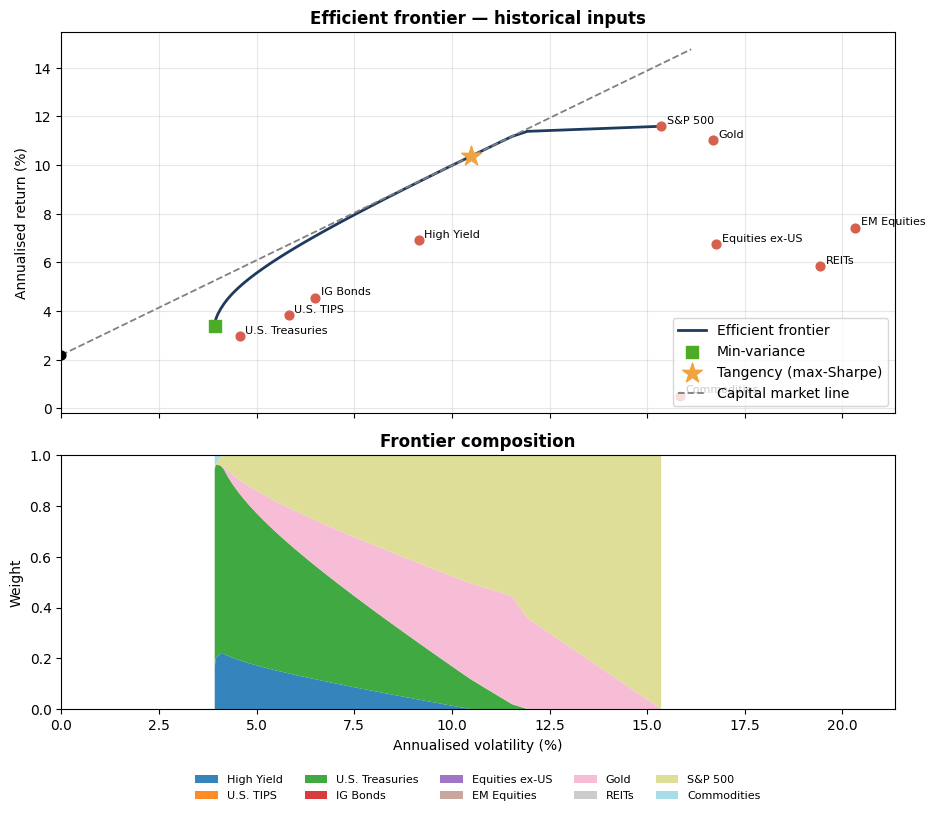

In [5]:
opt = MeanRiskOptimizer(solver="cvxpy")   # long-only, fully invested
V = Variance()

frontier = opt.efficient_frontier(mu_pct, S, V, "target_return", n_points=40)


def port_stats(w: pd.Series) -> tuple[float, float]:
    r = float(w.values @ mu_dec.reindex(w.index).values)
    vol = float(np.sqrt(w.values @ S.reindex(w.index, axis=0).reindex(w.index, axis=1).values @ w.values))
    return r, vol


fr = pd.DataFrame([port_stats(w) for w in frontier.values()], columns=["ret", "vol"])
frontier_w = pd.DataFrame(frontier).T          # rows: frontier points, cols: assets

# Tangency = max Sharpe ratio = MaxSharpe on EXCESS returns (mu - rf).
mu_excess_pct = mu_pct - rf * 100
w_minvar = opt.optimize(mu_pct, S, MinRisk(V))
w_tan = opt.optimize(mu_excess_pct, S, MaxSharpe())
r_mv, v_mv = port_stats(w_minvar)
r_tan, v_tan = port_stats(w_tan)

colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(rets.columns)))

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(9.5, 8.2), sharex=True, gridspec_kw={"height_ratios": [1.5, 1]}
)

# --- Top: frontier, assets, tangency, CML ---
ax.plot(fr["vol"] * 100, fr["ret"] * 100, "-", color="#1F3A5F", lw=2, label="Efficient frontier")
ax.scatter(np.sqrt(np.diag(S)) * 100, mu_dec.values * 100, s=40, color="#d6604d", zorder=5)
for a in rets.columns:
    ax.annotate(a, (np.sqrt(S.loc[a, a]) * 100, mu_dec[a] * 100),
                fontsize=8, xytext=(4, 2), textcoords="offset points")
ax.scatter([v_mv * 100], [r_mv * 100], marker="s", s=80, color="#4dac26",
           zorder=6, label="Min-variance")
ax.scatter([v_tan * 100], [r_tan * 100], marker="*", s=220, color="#f1a340",
           zorder=6, label="Tangency (max-Sharpe)")
xs = np.linspace(0, fr["vol"].max() * 100 * 1.05, 50)
ax.plot(xs, rf * 100 + (r_tan - rf) / v_tan * xs, "--",
        color="grey", lw=1.3, label="Capital market line")
ax.scatter([0], [rf * 100], marker="o", s=40, color="black", zorder=6)
ax.set_ylabel("Annualised return (%)")
ax.set_title("Efficient frontier — historical inputs", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim(left=0)

# --- Bottom: frontier composition (weights stacked vs volatility) ---
ax2.stackplot(fr["vol"] * 100, frontier_w.T.values,
              labels=frontier_w.columns, colors=colors, alpha=0.9)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Annualised volatility (%)")
ax2.set_ylabel("Weight")
ax2.set_title("Frontier composition", fontweight="bold")
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=5, fontsize=8, frameon=False)

fig.tight_layout()
plt.show()

## 5. Mean–variance optimization from scratch (`cvxpy`)

The framework optimizer is convenient, but it is worth seeing the convex program directly. For a
risk-aversion parameter $\gamma$ we maximise the quadratic utility

$$ U(w) = w^\top \mu - \gamma\, w^\top \Sigma w, \qquad \mathbf{1}^\top w = 1,\; w \ge 0. $$

Large $\gamma$ ⇒ conservative; small $\gamma$ ⇒ aggressive. (This is exactly what
`MaxUtility` builds inside `optimization.objectives`; here $\gamma = \lambda/2$.)

In [6]:
def mean_variance_optimization(mu, S, gamma):
    """Mean-variance optimization via quadratic utility and risk aversion.

    Args:
        mu: Expected returns of assets (pandas Series, decimal).
        S: Covariance matrix of asset returns (pandas DataFrame, decimal).
        gamma: Risk-aversion parameter (higher = more risk-averse).

    Returns:
        pandas Series of optimal weights.
    """
    n = len(mu)
    w = cp.Variable(n)
    ret = w @ mu.values
    risk = cp.quad_form(w, cp.psd_wrap(S.values))
    objective = cp.Maximize(ret - gamma * risk)
    constraints = [cp.sum(w) == 1, w >= 0]
    cp.Problem(objective, constraints).solve()
    return pd.Series(w.value, index=mu.index, name="Optimal Weights")


for gamma in (0.5, 2, 10):
    w = mean_variance_optimization(mu_dec, S, gamma)
    print(f"\nOptimal weights for gamma = {gamma}")
    print(w[w.abs() > 1e-3].round(3))


Optimal weights for gamma = 0.5
Gold      0.3320
S&P 500   0.6680
Name: Optimal Weights, dtype: float64

Optimal weights for gamma = 2
Gold      0.4240
S&P 500   0.5760
Name: Optimal Weights, dtype: float64

Optimal weights for gamma = 10
High Yield        0.1580
U.S. Treasuries   0.5590
Gold              0.1120
S&P 500           0.1710
Name: Optimal Weights, dtype: float64


### Tracing the frontier by sweeping $\gamma$

Varying $\gamma$ from very large (left, low risk) to very small (right, high risk) walks the
investor along the efficient frontier — the same curve the framework produced above.

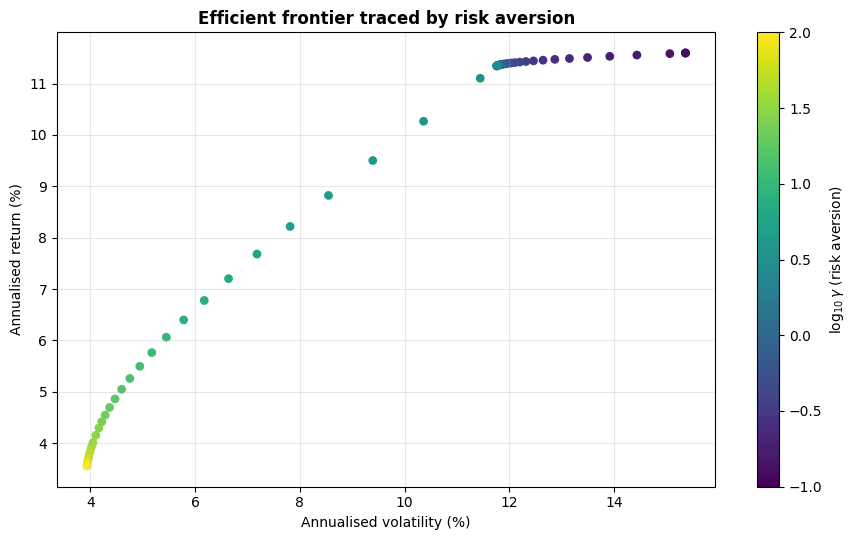

In [7]:
gammas = np.logspace(-1, 2, 60)
sweep = [mean_variance_optimization(mu_dec, S, g) for g in gammas]
sw = pd.DataFrame([port_stats(w) for w in sweep], columns=["ret", "vol"])

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(sw["vol"] * 100, sw["ret"] * 100, c=np.log10(gammas), cmap="viridis", s=28)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\log_{10}\gamma$ (risk aversion)")
ax.set_xlabel("Annualised volatility (%)")
ax.set_ylabel("Annualised return (%)")
ax.set_title("Efficient frontier traced by risk aversion", fontweight="bold")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Optimal portfolios under different objectives

This is the framework version of `saa/examples/run_static_optimization_example.py`, but driven
by the **historical** $\mu$ and sample $\Sigma$ instead of mock inputs. Each objective composes a
`Variance` risk measure; `MaxReturn` caps risk in variance units (a 10% volatility ceiling is a
variance ceiling of $0.10^2$). As in Section 4, `MaxSharpe` is solved on **excess** returns so it
returns the genuine highest-Sharpe (tangency) portfolio.

In [8]:
OBJECTIVES = [
    ("Min variance", MinRisk(risk_measure=V)),
    ("Max Sharpe", MaxSharpe()),
    ("Max utility (lam=2)", MaxUtility(risk_measure=V, risk_aversion=2.0)),
    ("Max utility (lam=10)", MaxUtility(risk_measure=V, risk_aversion=10.0)),
    ("Target return (6%)", TargetReturn(risk_measure=V, target_return=6.0)),
    ("Target vol (10%)", MaxReturn(risk_measure=V, max_risk=0.10**2)),
]


def full_stats(w):
    r, vol = port_stats(w)
    return {"Return (%)": r * 100, "Vol (%)": vol * 100, "Sharpe": (r - rf) / vol}


weights_all, stats_all = {}, {}
for label, obj in OBJECTIVES:
    # MaxSharpe needs excess returns to locate the tangency for this rf (see Section 4).
    inp = mu_excess_pct if isinstance(obj, MaxSharpe) else mu_pct
    w = opt.optimize(inp, S, obj)
    weights_all[label] = w
    stats_all[label] = full_stats(w)

weights_df = pd.DataFrame(weights_all).T
weights_df = weights_df.loc[:, (weights_df.abs() > 1e-4).any()]
print("Portfolio statistics"); print(pd.DataFrame(stats_all).T.round(2)); print()
print("Portfolio weights"); weights_df.round(3)

Portfolio statistics
                      Return (%)  Vol (%)  Sharpe
Min variance              3.3800   3.9300  0.3000
Max Sharpe               10.3700  10.4900  0.7800
Max utility (lam=2)      11.3700  11.8200  0.7800
Max utility (lam=10)      8.5600   8.2300  0.7700
Target return (6%)        6.0000   5.3900  0.7100
Target vol (10%)          9.9800  10.0000  0.7800

Portfolio weights


,High Yield,U.S. Treasuries,Gold,S&P 500,Commodities
Min variance,0.1450,0.7920,0.0000,0.0000,0.0630
Max Sharpe,0.0000,0.1170,0.3780,0.5050,0.0000
Max utility (lam=2),0.0000,0.0000,0.3930,0.6070,0.0000
Max utility (lam=10),0.0640,0.2980,0.2690,0.3690,0.0000
Target return (6%),0.1560,0.5550,0.1150,0.1740,0.0000
Target vol (10%),0.0140,0.1550,0.3550,0.4760,0.0000


### Weights by objective

A stacked bar chart makes the tilts obvious: the low-risk objectives load on bonds and real
estate, while the low-risk-aversion / high-return objectives concentrate in equities and gold.

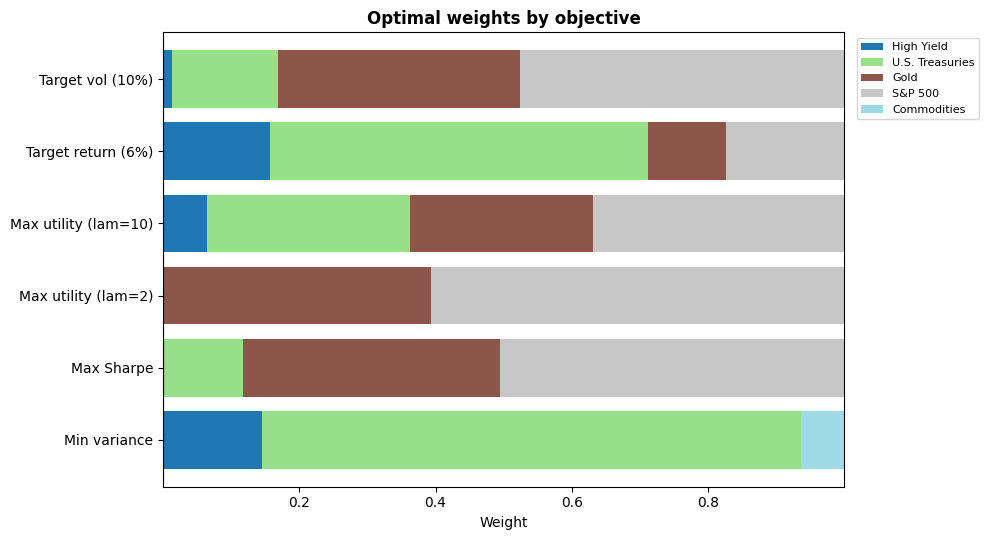

In [9]:
ax = weights_df.plot.barh(stacked=True, figsize=(10, 5.5), colormap="tab20", width=0.8)
ax.set_xlabel("Weight")
ax.set_title("Optimal weights by objective", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1.0), loc="upper left", fontsize=8)
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

## 7. The error maximizer: unconstrained vs. long-only

\citet{michaud1989} called mean–variance optimization an *error maximizer*: it loads
aggressively on whatever apparent signal-to-noise the inputs contain. Dropping the long-only
constraint reveals this — the optimizer takes large, offsetting long/short positions in the
correlated bond sleeves. The long-only constraint acts as implicit regularisation. (Both
tangency portfolios are solved on excess returns, as in Section 4.)

In [10]:
opt_ls = MeanRiskOptimizer(solver="cvxpy", long_only=False)
w_ls = opt_ls.optimize(mu_excess_pct, S, MaxSharpe())
w_lo = opt.optimize(mu_excess_pct, S, MaxSharpe())

cmp = pd.DataFrame({"Long/short": w_ls, "Long-only": w_lo})
r_ls, v_ls = port_stats(w_ls)
r_lo, v_lo = port_stats(w_lo)
print(f"Long/short tangency:  ret={r_ls*100:5.2f}%  vol={v_ls*100:5.2f}%  Sharpe={(r_ls-rf)/v_ls:.2f}")
print(f"Long-only tangency:   ret={r_lo*100:5.2f}%  vol={v_lo*100:5.2f}%  Sharpe={(r_lo-rf)/v_lo:.2f}")
print(f"Gross exposure:       long/short={w_ls.abs().sum():.2f}   long-only={w_lo.abs().sum():.2f}")
cmp.round(3)

Long/short tangency:  ret=13.74%  vol= 8.32%  Sharpe=1.39
Long-only tangency:   ret=10.37%  vol=10.49%  Sharpe=0.78
Gross exposure:       long/short=5.09   long-only=1.00


,Long/short,Long-only
High Yield,1.0050,0.0000
U.S. TIPS,-0.4080,0.0000
U.S. Treasuries,0.8680,0.1170
IG Bonds,-0.6170,0.0000
Equities ex-US,-0.2620,0.0000
EM Equities,-0.0880,0.0000
Gold,0.3740,0.3780
REITs,-0.3730,0.0000
S&P 500,0.7980,0.5050
Commodities,-0.2950,0.0000


### Perturbing the inputs: the error maximizer in action

The acid test of input sensitivity: add small **random errors of 0.5 percentage points** to the
expected returns — well within any real estimation error — and re-solve. The long/short tangency
portfolio lurches; the long-only portfolio barely moves. The constraint stops the optimizer from
chasing spurious signal-to-noise.

Applied errors (pp):
High Yield         0.1500
U.S. TIPS         -0.5200
U.S. Treasuries    0.3800
IG Bonds           0.4700
Equities ex-US    -0.9800
EM Equities       -0.6500
Gold               0.0600
REITs             -0.1600
S&P 500           -0.0100
Commodities       -0.4300

L1 weight change (sum|dw|):   L/S = 1.43   long-only = 0.48
Largest single-asset shift:   L/S = 0.38   long-only = 0.19
Gross exposure:   L/S 5.09 -> 5.05   long-only 1.00 -> 1.00


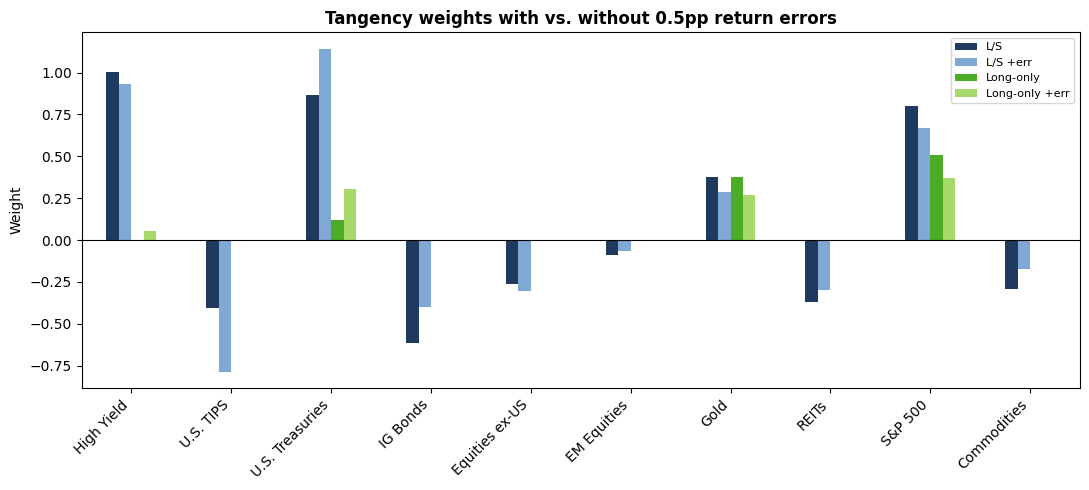

In [11]:
rng = np.random.default_rng(42)
err = pd.Series(rng.normal(0.0, 0.5, size=len(mu_pct)), index=mu_pct.index)  # 0.5 pp errors
mu_err_excess = (mu_pct + err) - rf * 100

w_ls_err = opt_ls.optimize(mu_err_excess, S, MaxSharpe())
w_lo_err = opt.optimize(mu_err_excess, S, MaxSharpe())

compare = pd.DataFrame({
    "L/S": w_ls, "L/S +err": w_ls_err,
    "Long-only": w_lo, "Long-only +err": w_lo_err,
}).round(3)

print("Applied errors (pp):"); print(err.round(2).to_string()); print()
print(f"L1 weight change (sum|dw|):   L/S = {(w_ls_err - w_ls).abs().sum():.2f}"
      f"   long-only = {(w_lo_err - w_lo).abs().sum():.2f}")
print(f"Largest single-asset shift:   L/S = {(w_ls_err - w_ls).abs().max():.2f}"
      f"   long-only = {(w_lo_err - w_lo).abs().max():.2f}")
print(f"Gross exposure:   L/S {w_ls.abs().sum():.2f} -> {w_ls_err.abs().sum():.2f}"
      f"   long-only {w_lo.abs().sum():.2f} -> {w_lo_err.abs().sum():.2f}")

ax = compare.plot.bar(figsize=(11, 5),
                      color=["#1F3A5F", "#7fa8d4", "#4dac26", "#a6d96a"])
ax.set_ylabel("Weight")
ax.set_title("Tangency weights with vs. without 0.5pp return errors", fontweight="bold")
ax.axhline(0, color="black", lw=0.8)
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Reading the chart.** The dark/light blue pairs (long/short) differ markedly — a 0.5pp
input wobble reshuffles the portfolio. The green pairs (long-only) are nearly identical. This is
the error-maximizer property in one picture: *the more freedom the optimizer has, the more it
amplifies estimation error.* Shrinkage, Black–Litterman, and robust optimisation (later lectures)
attack the same problem from the input side.

## Key takeaways

- `analytics.timeseries_analyzer` turns a price panel into a clean summary-statistics table;
  its annualised mean and the sample covariance are the optimizer's two inputs.
- `optimization.mean_risk` traces the efficient frontier (and its changing composition) and
  solves any objective (min-variance, max-Sharpe, max-utility, target-return/vol) over $(\mu, \Sigma)$.
- The tangency portfolio maximises the Sharpe ratio — solve `MaxSharpe` on **excess** returns so
  the capital market line is genuinely tangent to and dominates the frontier.
- Mean–variance is an **error maximizer**: tiny (0.5pp) errors in $\mu$ swing the unconstrained
  weights wildly, while long-only constraints keep them stable.